In [1]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "1"

import tensorflow as tf
import tensorflow_datasets as tfds

print("TF Version: ", tf.__version__)
print("TF Eager mode: ", tf.executing_eagerly())
print("TF GPU is", "available" if tf.config.list_physical_devices("GPU") else "not available")

2026-03-19 23:00:06.700802: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773954006.709185  109615 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773954006.711645  109615 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773954006.718787  109615 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773954006.718794  109615 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773954006.718795  109615 computation_placer.cc:177] computation placer alr

TF Version:  2.19.1
TF Eager mode:  True
TF GPU is available


In [3]:
# The size of a batch
BATCH_SIZE = 32
# The image size to use MobileNetV2 pre-trained model
IMAGE_SIZE = (224, 224)
# The image shape
IMAGE_SHAPE = IMAGE_SIZE + (3,)

## Prepare Datasets

In [4]:
# Download dataset directly from URL
data_dir = tf.keras.utils.get_file(
    origin="https://storage.googleapis.com/"
           "tensorflow-3-public/datasets/caltech_birds2010_011.zip",
    extract=True)

In [5]:
(raw_tr_ds, raw_ts_ds), ds_info = tfds.load("caltech_birds2010",
                                            split=["train", "test"],
                                            with_info=True,
                                            data_dir=data_dir,
                                            download=False)

I0000 00:00:1773954020.506564  109615 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6754 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6


In [6]:
print(f"Number of training examples: {len(raw_tr_ds)}")
print(f"Number of test examples: {len(raw_ts_ds)}")

Number of training examples: 3000
Number of test examples: 3033


In [8]:
def preprocess_sample(data):
    # Get image and bbox
    in_image, in_bbox = data["image"], data["bbox"]
    # Update bbox considering new image size
    s_shape = tf.cast(tf.shape(in_image), dtype=tf.float32)
    (sx, sy) = s_shape[1], s_shape[0]
    d_shape = tf.cast(IMAGE_SHAPE, dtype=tf.float32)
    (dx, dy) = d_shape[1], d_shape[0]
    out_bbox = [(in_bbox[1] * sx) / dx,
                (in_bbox[0] * sy) / dy,
                (in_bbox[3] * sx) / dx,
                (in_bbox[2] * sy) / dy]
    # Resize image to fit model
    out_image = tf.cast(in_image, dtype=tf.float32)
    out_image = tf.image.resize(out_image, size=IMAGE_SIZE)
    # Pre-process image to fit model
    out_image = tf.keras.applications.mobilenet.preprocess_input(out_image)
    return out_image, out_bbox

In [9]:
tr_ds = (raw_tr_ds
         .map(preprocess_sample)
         .shuffle(buffer_size=1000)
         .batch(BATCH_SIZE)
         .prefetch(tf.data.AUTOTUNE))

ts_ds = (raw_ts_ds
         .map(preprocess_sample)
         .cache()
         .batch(BATCH_SIZE)
         .prefetch(tf.data.AUTOTUNE))

## Create Model

* Get the architecture of existing model
* Use existing weights
* Add layers to predict bounding boxes (regression)

In [10]:
inputs = tf.keras.layers.Input(shape=IMAGE_SHAPE)
x = tf.keras.applications.MobileNetV2(
      input_shape=IMAGE_SHAPE,
      include_top=False,
      weights="imagenet"
)(inputs)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(1024, activation="relu")(x)
x = tf.keras.layers.Dense(512, activation="relu")(x)
outputs = tf.keras.layers.Dense(4)(x) # 4 units as we need to predict bbox (xmin, ymin, xmax, ymax)
model = tf.keras.Model(inputs=inputs, outputs=outputs)

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(momentum=0.9),
    loss="mse")

### Train Model

In [12]:
EPOCHS = 3

tr_len = len(raw_tr_ds)
ts_len = len(raw_ts_ds)
tr_steps = math.ceil(tr_len / BATCH_SIZE)
ts_steps = math.ceil(ts_len / BATCH_SIZE)

history = model.fit(
    tr_ds,
    steps_per_epoch=tr_steps,
    validation_data=ts_ds,
    validation_steps=ts_steps,
    epochs=EPOCHS)

Epoch 1/3


I0000 00:00:1773954041.126123  109773 service.cc:152] XLA service 0x7f7348002b70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773954041.126154  109773 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
I0000 00:00:1773954041.802566  109773 cuda_dnn.cc:529] Loaded cuDNN version 90300


 3/94 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.5074  

I0000 00:00:1773954051.775919  109773 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


94/94 ━━━━━━━━━━━━━━━━━━━━ 36s 211ms/step - loss: 0.1350 - val_loss: 0.8049
Epoch 2/3
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 0.0544 - val_loss: 0.4674
Epoch 3/3
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 0.0353 - val_loss: 0.3256


### Evaluate Model

In [13]:
loss = model.evaluate(ts_ds, steps=ts_steps)

95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3256


#### Plot Metrics

In [14]:
def plot_metrics(metric_name, title, ylim=5):
    plt.title(title)
    plt.ylim(0,ylim)
    plt.plot(history.history[metric_name],color='blue',label=metric_name)
    plt.plot(history.history['val_' + metric_name],color='green',label='val_' + metric_name)

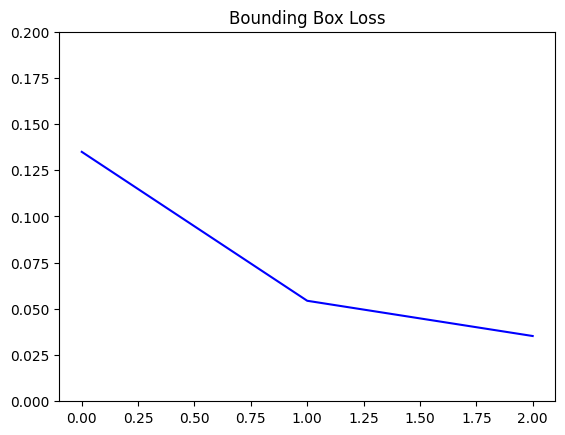

In [15]:
plot_metrics("loss", "Bounding Box Loss", ylim=0.2)

#### Calculate IoU

In [16]:
def intersection_over_union(pred_box, true_box):
    xmin_pred, ymin_pred, xmax_pred, ymax_pred =  np.split(pred_box, 4, axis = 1)
    xmin_true, ymin_true, xmax_true, ymax_true = np.split(true_box, 4, axis = 1)
    # Calculate coordinates of overlap area between boxes
    xmin_overlap = np.maximum(xmin_pred, xmin_true)
    xmax_overlap = np.minimum(xmax_pred, xmax_true)
    ymin_overlap = np.maximum(ymin_pred, ymin_true)
    ymax_overlap = np.minimum(ymax_pred, ymax_true)
    # Calculates area of true and predicted boxes
    pred_box_area = (xmax_pred - xmin_pred) * (ymax_pred - ymin_pred)
    true_box_area = (xmax_true - xmin_true) * (ymax_true - ymin_true)
    # Calculates overlap area and union area.
    overlap_area = np.maximum((xmax_overlap - xmin_overlap),0)  * np.maximum((ymax_overlap - ymin_overlap), 0)
    union_area = (pred_box_area + true_box_area) - overlap_area
    # Defines a smoothing factor to prevent division by 0
    smoothing_factor = 1e-10
    # Updates iou score
    iou = (overlap_area + smoothing_factor) / (union_area + smoothing_factor)
    return iou

In [17]:
# Split and convert to numpy array
it = list(ts_ds.unbatch().take(100).as_numpy_iterator())
true_images = np.array([item[0] for item in it])
true_bboxes = np.array([item[1] for item in it])

In [18]:
# Predict bboxes
pred_bboxes = model.predict(true_images)

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step


In [19]:
# Calculate IoU
iou = intersection_over_union(pred_bboxes, true_bboxes)
iou_threshold = 0.5

In [20]:
print(f"Number of predictions where iou >= threshold ({iou_threshold}): {(iou >= iou_threshold).sum()}")
print(f"Number of predictions where iou <  threshold ({iou_threshold}): {(iou <  iou_threshold).sum()}")

Number of predictions where iou >= threshold (0.5): 10
Number of predictions where iou <  threshold (0.5): 90
